[ 2026_0615_비젼 과제] ----------------------------------------

1. [복습 우선]
   허프 변환 선/원 추출 까지 직접 실습한 코드 제출하세요.

In [2]:
import cv2
import numpy as np
import sys
sys.path.append('..')
from cv_utils import *

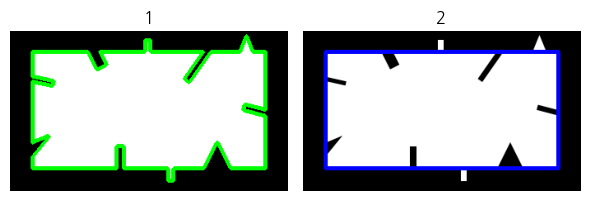

In [3]:
# 컨투어 단순화 - 근사 컨투어
img = cv2.imread('../Data/images/bad_rect.png')
img2 = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, th = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

contours, hierachy = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[-2:]

contour = contours[0]

epsilon = 0.05 * cv2.arcLength(contour, True)

approx = cv2.approxPolyDP(contour, epsilon, True)

cv2.drawContours(img, [contour], -1, (0,255,0), 3)
cv2.drawContours(img2, [approx], -1, (0,0,255), 3)

printPlots(1,2, [1,2], [img,img2])

False True


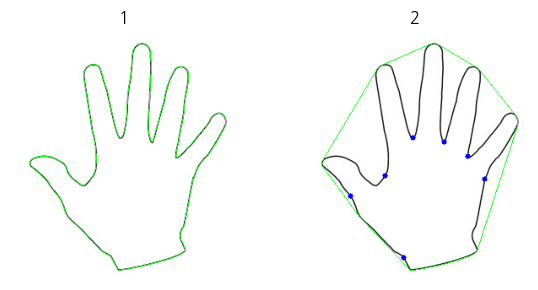

In [4]:
# 컨투어 단순화 - 블록 선체
img = cv2.imread('../Data/images/hand.jpg')
img2 = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, th = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

contours, hierachy = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[-2:]

cntr = contours[0]
cv2.drawContours(img, [cntr], -1, (0,255,0), 1)

hull = cv2.convexHull(cntr)
cv2.drawContours(img2, [hull], -1, (0,255,0), 1)

print(cv2.isContourConvex(cntr), cv2.isContourConvex(hull))

hull2 = cv2.convexHull(cntr, returnPoints=False)

defects = cv2.convexityDefects(cntr, hull2)

for i in range(defects.shape[0]):
    startP, endP, farthestP, distance = defects[i,0]

    farthest =  tuple(cntr[farthestP][0])

    dist = distance/256.0

    if dist > 1: cv2.circle(img2, farthest, 3, (0,0,255), -1)

printPlots(1,2, [1,2], [img,img2])

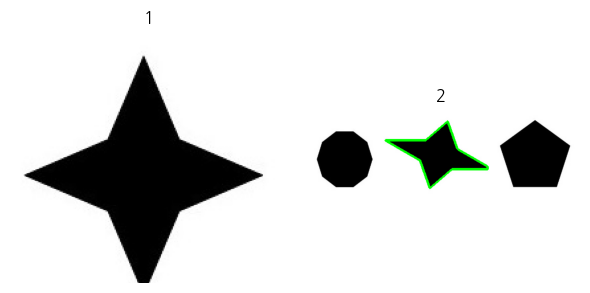

In [5]:
# 컨투어 도형 매칭
target = cv2.imread('../Data/images/4star.jpg')
shapes = cv2.imread('../Data/images/shapestomatch.jpg')

target_g = cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)
shapes_g = cv2.cvtColor(shapes, cv2.COLOR_BGR2GRAY)

ret, t_th = cv2.threshold(target_g, 127, 255, cv2.THRESH_BINARY_INV)
ret, s_th = cv2.threshold(shapes_g, 127, 255, cv2.THRESH_BINARY_INV)

t_cntr, hierachy = cv2.findContours(t_th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[-2:]
s_cntr, hierachy = cv2.findContours(s_th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[-2:]

matchs = [ (cv2.matchShapes(t_cntr[0], cntr, cv2.CONTOURS_MATCH_I2, 0.0), cntr) for cntr in s_cntr ]
matchs.sort(key=lambda x:x[0])

cv2.drawContours(shapes, [matchs[0][1]], -1, (0,255,0), 3)

printPlots(1,2, [1,2], [target,shapes])

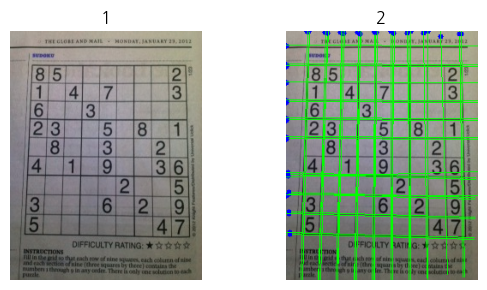

In [6]:
# 허프 선 검출
img = cv2.imread('../Data/images/sudoku.jpg')
img2 = img.copy()
h, w = img.shape[:2]

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 100, 200)
lines = cv2.HoughLines(edges, 1, np.pi/180, 130)

for line in lines:
    r, theta = line[0]
    tx, ty = np.cos(theta), np.sin(theta)
    x0, y0 = tx*r, ty*r

    cv2.circle(img2, (int(abs(x0)),int(abs(y0))), 3, (0,0,255), -1)

    x1, y1 = int(x0 + w*(-ty)), int(y0 + h * tx)
    x2, y2 = int(x0 - w*(-ty)), int(y0 - h * tx)

    cv2.line(img2, (x1,y1), (x2,y2), (0,255,0), 1)

printPlots(1,2, [1,2], [img,img2])

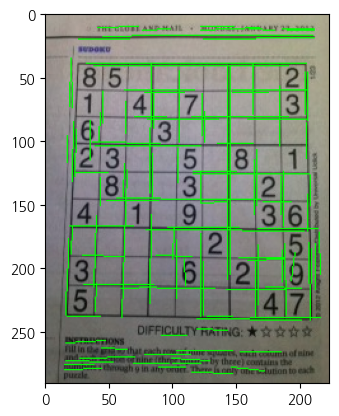

In [7]:
img = cv2.imread('../Data/images/sudoku.jpg')
img2 = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 50, 200)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 10, None, 20, 2)

for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 1)
    plt.imshow(img)

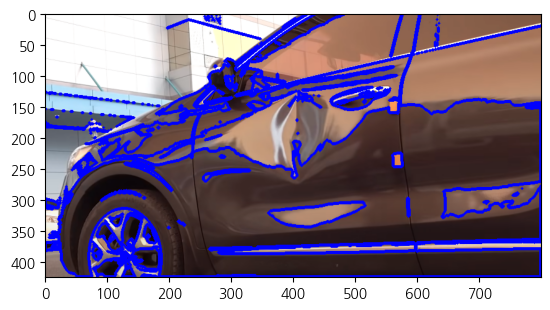

In [9]:
img = cv2.imread('../Data/images/car2.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, th = cv2.threshold(gray, 80, 255, cv2.THRESH_BINARY_INV)

contours, hierachy = cv2.findContours(th, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)[-2:]
# print(len(contours), hierachy)

cv2.drawContours(img, contours, -1, (0,0,255), 4)
plt.imshow(img)

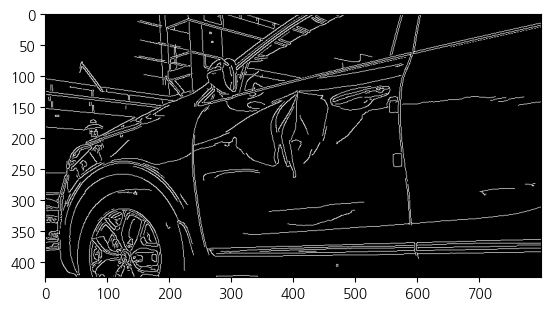

In [10]:
img = cv2.imread('../Data/images/car2.png')
# img = cv2.imread('../Data/images/sudoku.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (3, 3), 0)
edges   = cv2.Canny(blurred, 50, 100)
plt.imshow(edges, cmap='gray')
plt.show()

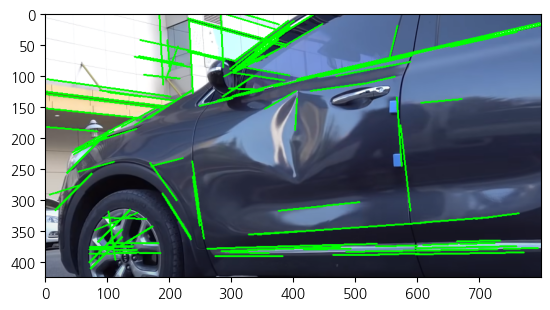

In [11]:
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 60, minLineLength=50, maxLineGap=10)

line_img = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))

[[  0.   0.   0. ...  -2.   0.   0.]
 [  0.   0.   0. ...  -7.  -3.   0.]
 [  0.   0.   0. ... -18. -12.   0.]
 ...
 [  0.  19.  -1. ...   0.   0.   0.]
 [  0.  42.  54. ...   0.   0.   0.]
 [  0.  52.  78. ...   0.   0.   0.]]


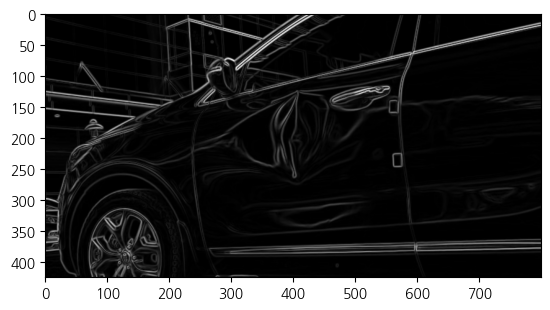

In [12]:
# Sobel 필터를 이용해 경계의 기울기 강조
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
print(sobelx)

# 기울기의 크기 계산
magnitude = np.sqrt(sobelx**2 + sobely**2)
magnitude = np.uint8(255 * magnitude / np.max(magnitude))

plt.imshow(magnitude, cmap='gray')

2. 상용 수준의 손 제스처 인식은 피부색 분리, 배경 제거, 손 추적 등의 추가 
   작업이 필요하지만, Convex Hull + Convexity Defects 원리를 학습하기 
   위한 문제로 구현해 주시면 됩니다. 
   - 손 펴기 | 주먹 | 브이 

3. 알약 사진에서 알약의 개수를 감지해서 출력해 주세요.   
   - 이미지 : pill.png

감지된 알약 수: 10개


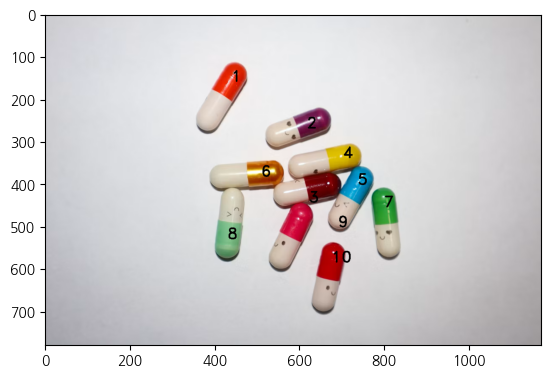

In [ ]:
img = cv2.imread('../Data/images/pill.png')

img = cv2.imread('../Data/images/pill.png')
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

h = hsv[:, :, 0]  # 색상 
s = hsv[:, :, 1]  # 채도 
v = hsv[:, :, 2]  # 명도

# 모폴로지 연산
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

# 채도 > 60 AND 명도 > 50 인 픽셀만 흰색(255)으로, 나머지는 검정(0)으로 마스크 생성
mask = ((s > 60) & (v > 50)).astype(np.uint8) * 255
# 노이즈 제거
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)
# 구멍 메우기
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)

# n_l: 레이블 수, lbl: 각 픽셀의 레이블 맵, sts: 각 컴포넌트 통계, cents: 각 컴포넌트 무게중심
n_l, lbl, sts, cents = cv2.connectedComponentsWithStats(mask)

pill_centers = []  # 감지된 알약 중심 좌표 목록

for i in range(1, n_l):  # 0번은 배경이므로 1번부터 순회
    area = sts[i, cv2.CC_STAT_AREA]  # 해당 컴포넌트의 픽셀 면적
    if area < 200:  # 너무 작은 노이즈 컴포넌트 제외
        continue
    cx, cy = int(cents[i][0]), int(cents[i][1])  # 무게중심 좌표

    if area < 12000:
        # 단일 알약 → 무게중심을 중심점으로 바로 사용
        pill_centers.append((cx, cy))
    else:
        # 겹친 알약 → h 히스토그램 피크로 색상별 분리
        blob_mask = (lbl == i).astype(np.uint8)       # 해당 컴포넌트 영역만 추출
        hs_here   = h[blob_mask == 1]                 # 해당 영역의 Hue 값
        sats_here = s[blob_mask == 1]                 # 해당 영역의 채도 값
        vals_here = v[blob_mask == 1]                 # 해당 영역의 명도 값

        # 채도·명도가 충분히 높은(선명한) 픽셀만 선택
        high = (sats_here > 80) & (vals_here > 60)
        if not high.any():  # 선명한 픽셀이 없으면 무게중심 1개로 처리
            pill_centers.append((cx, cy))
            continue

        hs_high = hs_here[high]  # 선명한 픽셀의 Hue 값만 추출

        # Hue 히스토그램 계산 (0~179, 180개 구간)
        hist, _ = np.histogram(hs_high, bins=180, range=(0, 180))

        # 로컬 최댓값(피크) 추출 (윈도우=8, 최소 높이=30)
        window = 8
        min_h  = 30
        peaks  = []
        for b in range(len(hist)):
            if hist[b] < min_h:  # 최소 높이 미만이면 스킵
                continue
            lo = max(0, b - window)
            hi = min(len(hist), b + window + 1)
            if hist[b] == hist[lo:hi].max():  # 주변 윈도우 내에서 최대값이면 피크
                # 이미 가까운 피크가 있으면 더 큰 값으로 교체
                if peaks and b - peaks[-1] < window:
                    if hist[b] > hist[peaks[-1]]:
                        peaks[-1] = b
                else:
                    peaks.append(b)

        if not peaks:  # 피크가 없으면 무게중심 1개로 처리
            pill_centers.append((cx, cy))
            continue

        # 각 Hue 피크 → 해당 색상 픽셀들의 공간 중심점 계산
        h_range = 12  # 피크 기준 ±12 범위의 Hue를 같은 색으로 간주
        for pk in peaks:
            h_lo = max(0,   pk - h_range)
            h_hi = min(180, pk + h_range)

            if pk < h_range:  # 빨강(Hue≈0)은 0과 180이 이어지므로 wrap-around 처리
                sub_mask = blob_mask * (
                    ((h >= 0) & (h <= pk + h_range)) |
                    ((h >= 180 - h_range + pk) & (h <= 180))
                ).astype(np.uint8)
            else:
                sub_mask = blob_mask * (
                    (h >= h_lo) & (h <= h_hi)
                ).astype(np.uint8)
            sub_mask &= (s > 80).astype(np.uint8)  # 채도 낮은 픽셀 제외

            pts = np.where(sub_mask > 0)  # 해당 색상 픽셀 좌표
            if len(pts[0]) < 50:          # 픽셀 수가 너무 적으면 스킵
                continue

            scx = int(np.mean(pts[1]))  # x 평균 → 중심 x
            scy = int(np.mean(pts[0]))  # y 평균 → 중심 y

            # 55px 이내에 이미 등록된 중심점이 있으면 중복으로 판단하고 스킵
            too_close = any(
                abs(scx - ex) < 55 and abs(scy - ey) < 55
                for ex, ey in pill_centers
            )
            if not too_close:
                pill_centers.append((scx, scy))

pill_count = len(pill_centers)
print(f"감지된 알약 수: {pill_count}개")

result = rgb.copy()
for i, (x, y) in enumerate(pill_centers, 1): cv2.putText(result, str(i), (x, y), cv2.FONT_HERSHEY_DUPLEX, 1.2, (0, 0, 0), 2)
plt.imshow(result);

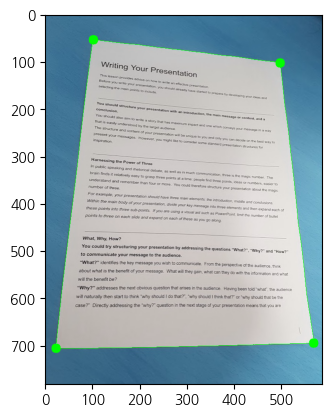

In [ ]:
win_name = 'scan'

img = cv2.imread('../Data/images/paper.jpg')
draw = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (3,3), 0)
edged = cv2.Canny(gray, 75, 200)

cnts, _ = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[-2:]

cv2.drawContours(draw, cnts, -1, (0,255,0))

cnts = sorted(cnts, key = cv2.contourArea, reverse=True)[:5]
for c in cnts:
    peri = cv2.arcLength(c, True)

    vertices = cv2.approxPolyDP(c, 0.02 * peri, True)
    if len(vertices) == 4:
        break
pts = vertices.reshape(4, 2)
for x, y in pts:
    cv2.circle(draw, (x,y), 10, (0,255,0), -1)

merged = np.hstack((img, draw))

sm = pts.sum(axis=1)
diff = np.diff(pts, axis = 1)

topLeft = pts[np.argmin(sm)]
bottomRight = pts[np.argmax(sm)]
topRight = pts[np.argmin(diff)]
bottomLeft = pts[np.argmax(diff)]

pts1 = np.float32([topLeft, topRight, bottomRight, bottomLeft])

w1 = abs(bottomRight[0] - bottomLeft[0])
w2 = abs(topRight[0] - bottomLeft[0])
h1 = abs(topRight[0] - bottomRight[1])
h2 = abs(topLeft[0] - bottomLeft[1])
width = max([w1, w2])
height = max([h1, h2])

pts2 = np.float32([[0,0], [width-1,0], [width-1, height-1], [0,height-1]])

mtrx = cv2.getPerspectiveTransform(pts1, pts2)

result = cv2.warpPerspective(img, mtrx, (width, height))
plt.imshow(draw)

13개


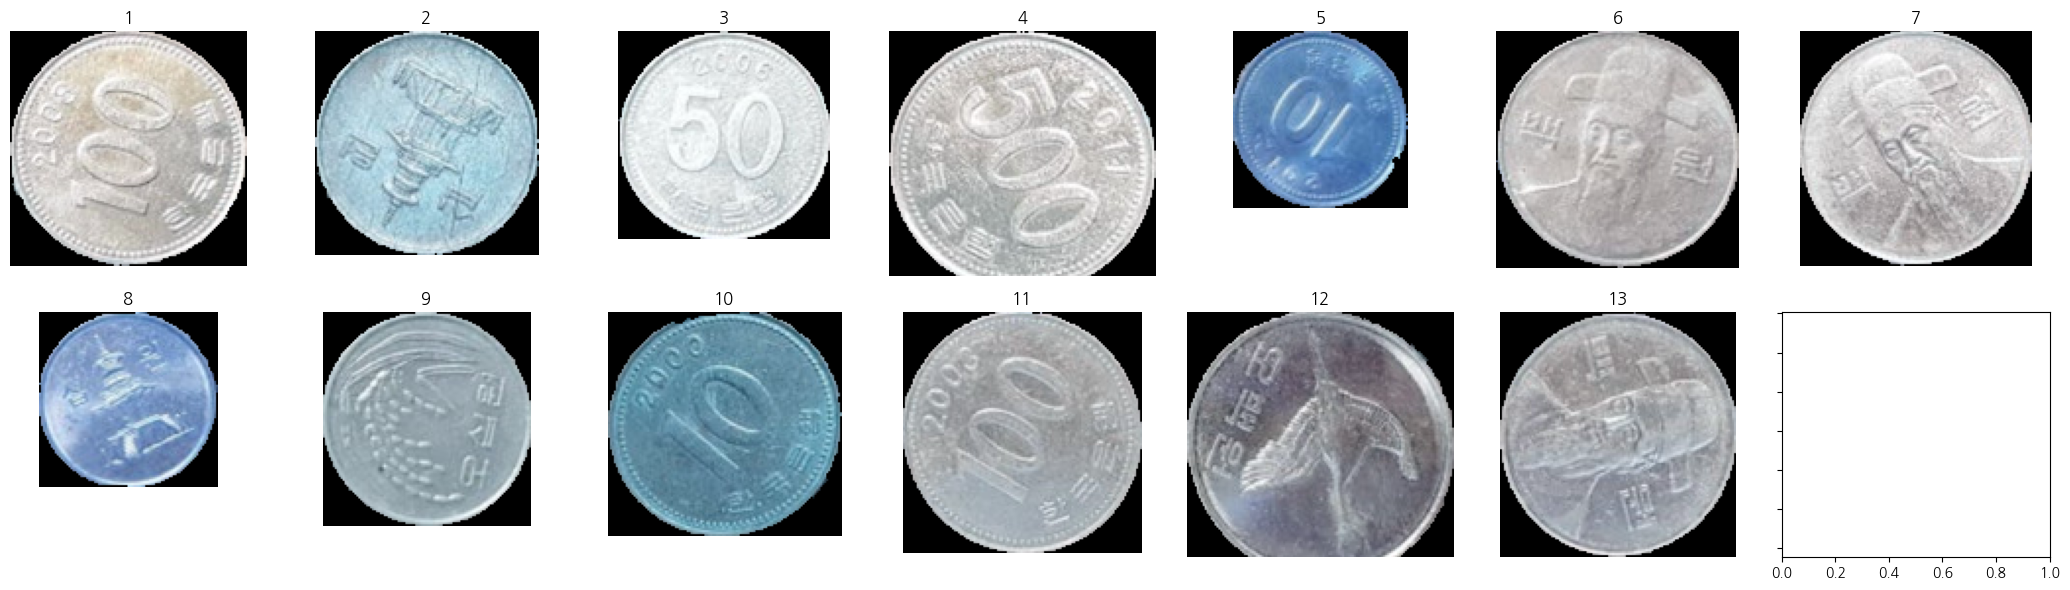

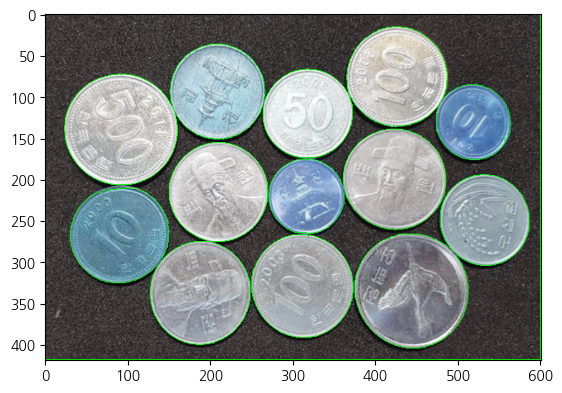

In [ ]:
img = cv2.imread('../Data/images/coins_connected.jpg')
rows, cols = img.shape[:2]

mean = cv2.pyrMeanShiftFiltering(img, 20, 50)
gray = cv2.cvtColor(mean, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (3,3), 0)

_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

dst = cv2.distanceTransform(thresh, cv2.DIST_L2, 3)
dst = (dst / (dst.max() - dst.min()) * 255).astype(np.uint8)

localMx = cv2.dilate(dst, np.ones((50,50), np.uint8))

lm = np.zeros((rows, cols), np.uint8)

lm[(localMx==dst) & (dst != 0)] = 255

seeds = np.where(lm == 255)
seed = np.stack((seeds[1], seeds[0]), axis=-1)

fill_mask = np.zeros((rows+2, cols+2), np.uint8)
for x, y in seed: ret = cv2.floodFill(mean, fill_mask, (x,y), (255,255,255), (10,10,10), (10,10,10))

gray = cv2.cvtColor(mean, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (5,5), 0)

ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
dst = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
dst = ((dst / (dst.max() - dst.min())) * 255).astype(np.uint8)

ret, sure_fg = cv2.threshold(dst, 0.5*dst.max(), 255,0)

_, bg_th = cv2.threshold(dst, 0.3*dst.max(), 255, cv2.THRESH_BINARY_INV)
bg_dst = cv2.distanceTransform(bg_th, cv2.DIST_L2, 5)
bg_dst = ((bg_dst / (bg_dst.max() - dst.min())) * 255).astype(np.uint8)
ret, sure_bg = cv2.threshold(bg_dst, 0.3*bg_dst.max(), 255,cv2.THRESH_BINARY)

ret, inv_sure_bg = cv2.threshold(sure_bg, 127, 255, cv2.THRESH_BINARY_INV)
unknown = cv2.subtract(inv_sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)

markers = markers+1
markers[unknown == 255] = 0

colors = []
marker_show = np.zeros_like(img)
for mid in np.unique(markers):
    color = [int(j) for j in np.random.randint(0, 255, 3)]
    colors.append((mid, color))
    marker_show[markers==mid] = color
    coords = np.where(markers==mid)
    x, y = coords[1][0], coords[0][0]
    cv2.putText(marker_show, str(mid), (x+20, y+20), cv2.FONT_HERSHEY_PLAIN, 2, (255,255,255))

markers = cv2.watershed(img, markers)

for mid, color in colors:
    marker_show[markers==mid] = color
    coords = np.where(markers==mid)
    if coords[0].size <= 0: continue

    x,y = coords[1][0], coords[0][0]
    cv2.putText(marker_show, str(mid), (x+20, y+20), cv2.FONT_HERSHEY_PLAIN, 2, (255,255,255))

marker_show[markers==-1] = (0,255,0)

img[markers==-1] = (0,255,0)

mask = np.zeros((rows, cols), np.uint8)

mask[markers!=1] = 255

nobg = cv2.bitwise_and(img, img, mask=mask)

coin_label = [l for l in np.unique(markers) if (l != 1 and l != -1)]

c = []
for i, label in enumerate(coin_label):
    mask[:,:] = 0
    mask[markers == label] = 255
    coins = cv2.bitwise_and(img, img, mask=mask)
    contour, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)[-2:]

    x,y,w,h = cv2.boundingRect(contour[0])

    coin = coins[y:y+h, x:x+w]
    c.append(coin)

    # plt.imshow(coin)
    # plt.show()
print(f'{len(c)}개')
printPlots(2,7,[i+1 for i in range(len(c))], c)
plt.imshow(img)